# Research Workflow

This notebook demonstrates the research [workflow](https://langchain-ai.github.io/langgraph/tutorials/workflows/) that creates comprehensive reports through a series of focused steps. The system:

1. Uses a **graph workflow** with specialized nodes for each report creation stage
2. Enables user **feedback and approval** at critical planning points 
3. Produces a well-structured report with introduction, researched body sections, and conclusion

## From repo 

In [1]:
%cd ..
%load_ext autoreload
%autoreload 2

c:\Users\User\OneDrive\1_AI\open_deep_research_gz\src


## From package 

In [2]:
# ! pip install -U -q open-deep-research
! pip show open-deep-research

Name: open_deep_research
Version: 0.0.16
Summary: Planning, research, and report generation.
Home-page: 
Author: Lance Martin
Author-email: 
License: MIT
Location: C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages
Editable project location: C:\Users\User\OneDrive\1_AI\open_deep_research_gz
Requires: arxiv, azure-identity, azure-search, azure-search-documents, beautifulsoup4, duckduckgo-search, exa-py, httpx, ipykernel, langchain-anthropic, langchain-aws, langchain-community, langchain-deepseek, langchain-google-genai, langchain-google-vertexai, langchain-groq, langchain-mcp-adapters, langchain-openai, langchain-tavily, langgraph, langgraph-cli, langsmith, linkup-sdk, markdownify, mcp, openai, pandas, pymupdf, pytest, python-dotenv, requests, rich, supabase, tavily-python, xmltodict
Required-by: 


# Compile the Graph-Based Research Workflow

The next step is to compile the LangGraph workflow that orchestrates the report creation process. This defines the sequence of operations and decision points in the research pipeline.

In [3]:
# Import required modules and initialize the builder from open_deep_research
import uuid 
import os, getpass
import open_deep_research   
print(open_deep_research.__version__) 
from IPython.display import Image, display, Markdown
from langgraph.types import Command
from langgraph.checkpoint.memory import MemorySaver
from open_deep_research.deep_researcher import deep_researcher_builder as builder

0.0.16


In [4]:
# Create a memory-based checkpointer and compile the graph
# This enables state persistence and tracking throughout the workflow execution

memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

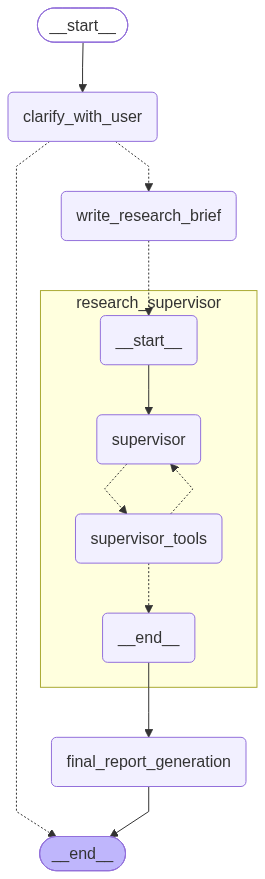

In [5]:
# Visualize the graph structure
# This shows the nodes and edges in the research workflow

display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [6]:
# Helper function to set environment variables for API keys
# This ensures all necessary credentials are available for various services

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

# Set the API keys used for any model or search tool selections below, such as:
_set_env("GOOGLE_API_KEY")
# _set_env("ANTHROPIC_API_KEY")
_set_env("TAVILY_API_KEY")
# _set_env("GROQ_API_KEY")
# _set_env("PERPLEXITY_API_KEY")

In [9]:
# Define report structure template and configure the research workflow
# This sets parameters for models, search tools, and report organization

REPORT_STRUCTURE = """Use this structure to create a report on the user-provided topic:

1. Introduction (no research needed)
   - Brief overview of the topic area

2. Main Body Sections:
   - Each section should focus on a sub-topic of the user-provided topic
   
3. Conclusion
   - Aim for 1 structural element (either a list of table) that distills the main body sections 
   - Provide a concise summary of the report"""

# Configure the current graph implementation with Google GenAI models
thread = {"configurable": {"thread_id": str(uuid.uuid4()),
                           "search_api": "tavily",
                           "research_model": "google_genai:gemini-3.7-flash",
                           "summarization_model": "google_genai:gemini-3.7-flash",
                           "compression_model": "google_genai:gemini-3.7-flash",
                           "final_report_model": "google_genai:gemini-3.7-flash",
                           "max_search_depth": 2,
                           "report_structure": REPORT_STRUCTURE,
                           }}

# Define research topic about Model Context Protocol
topic = "Overview of Model Context Protocol (MCP), an Anthropic-backed open standard for integrating external context and tools with LLMs. Give an architectural overview for developers, tell me about interesting MCP servers, and compare to Google Agent2Agent (A2A) protocol."

# Run the graph workflow until first interruption (waiting for user feedback)
async for event in graph.astream({"topic": topic}, thread, stream_mode="updates"):
    if '__interrupt__' in event:
        interrupt_value = event['__interrupt__'][0].value
        display(Markdown(interrupt_value))

# User Feedback Phase

* This allows for providing directed feedback on the initial report plan
* The user can review the proposed report structure and provide specific guidance
* The system will incorporate this feedback into the final report plan

In [10]:
# Submit feedback on the report plan
# The system will continue execution with the updated requirements

# Provide specific feedback to focus and refine the report structure
async for event in graph.astream(Command(resume="Looks great! Just do one section related to Agent2Agent (A2A) protocol, introducing it and comparing to MCP."), thread, stream_mode="updates"):
    if '__interrupt__' in event:
        interrupt_value = event['__interrupt__'][0].value
        display(Markdown(interrupt_value))

# Final Approval Phase
* After incorporating feedback, approve the plan to start content generation

In [11]:
# Approve the final plan and execute the report generation
# This triggers the research and writing phases for all sections

# The system will now:
# 1. Research each section topic
# 2. Generate content with citations
# 3. Create introduction and conclusion
# 4. Compile the final report

async for event in graph.astream(Command(resume=True), thread, stream_mode="updates"):
    print(event)
    print("\n")

In [ ]:
# Display the final generated report
# Retrieve the completed report from the graph's state and format it for display

final_state = graph.get_state(thread)
report = final_state.values.get('final_report')
print(report)

None


In [19]:
final_state = graph.get_state(thread)

print(final_state.values.keys())
print(final_state.values.get("final_report", "Report has not been generated yet."))


dict_keys(['messages', 'supervisor_messages', 'raw_notes', 'notes'])
Report has not been generated yet.


In [ ]:
# To verify whether generation completed:
# You should see final_report among the keys. If it is missing, the workflow has not completed or the report-generation cell failed.
print(final_state.values.keys())

dict_keys(['messages', 'supervisor_messages', 'raw_notes', 'notes'])


Trace: 

> Note: uses 80k tokens 

https://smith.langchain.com/public/31eca7c9-beae-42a3-bef4-5bce9488d7be/r